In [30]:
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import numpy as np
import pickle
import os, shutil, yaml, glob

from matplotlib import pyplot as plt
from pylab import *

In [34]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from PIL import Image

In [35]:
ROOT_PATH = './'

In [36]:
nblocks, cutoff, threebody_cutoff = 3, 4.0, 4.0

In [37]:
GRID=np.linspace(9500-600, 9650-600, 1000)
energy_grid = GRID[333:733:2]

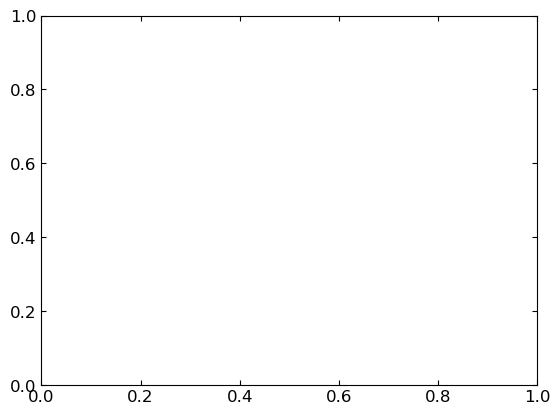

In [38]:
plot_kwargs = {
    'linewidth': 1.5,
    'marker': 's',
    'ms': 4.0,
    'capthick': 0.3,
    'capsize': 2.0,
    'elinewidth': 0.3
}

plt.clf()
plt.rc("font", size=12)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.tick_params(bottom = True, top = True, left = True, right = True)

In [39]:
SHIFT = 705.3   ## Global shift between simulated and experimental spectra 
scale_predicted = 19.84 / 20   ## Scale between simulated / predicted and experimnetal spectra 

### 1. Decile plots of test dataset

In [9]:
data_decile = pickle.load(open('./data/test_dataset-decile.pkl', 'rb'))

(-0.1, 2.7)

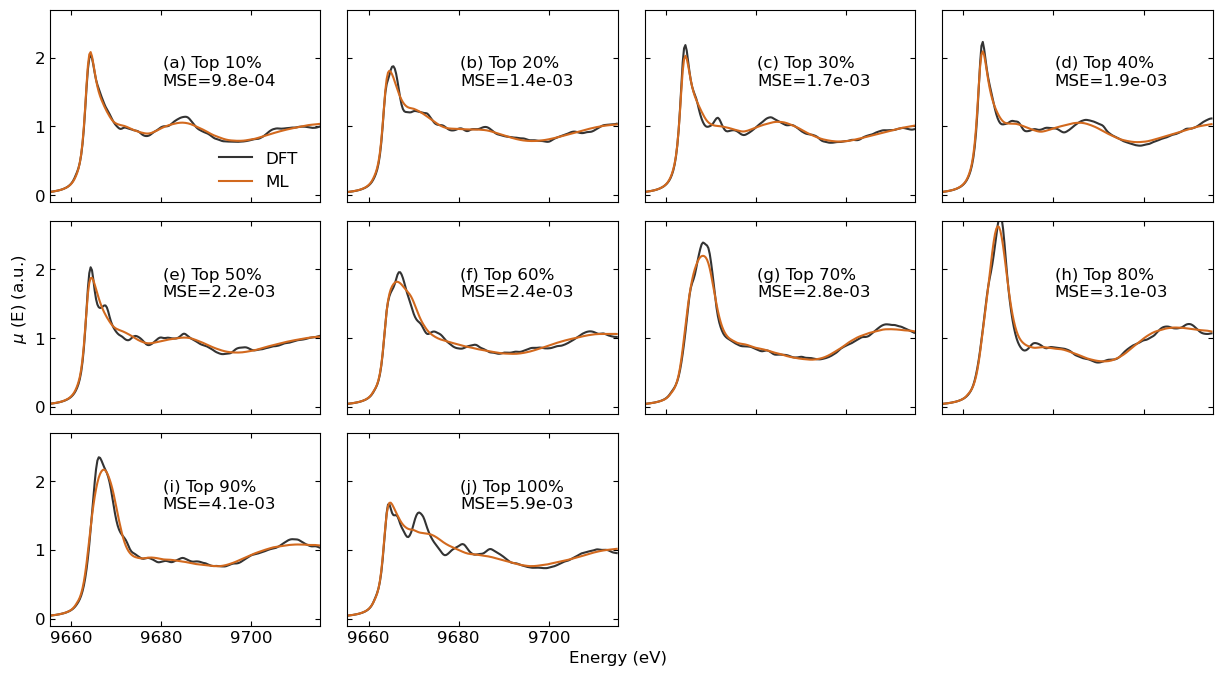

In [10]:
close('all')
plt.rc("font", size=12)
fig, axs = plt.subplots(3, 4, figsize=(15, 8), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

axs = axs.flatten()
labels = 'abcdefghij'

for top_i in data_decile: 
    ax = axs[top_i]
    sp, pred, loss = data_decile[top_i]['spectrum'], data_decile[top_i]['prediction'], data_decile[top_i]['loss']
    ax.plot(energy_grid+SHIFT, scale_predicted*sp, color='#333333', label='DFT')
    ax.plot(energy_grid+SHIFT, scale_predicted*pred, color='chocolate', label='ML')
    ax.annotate('(' + labels[top_i] + r') Top {:1.0f}%'.format(top_i*10+10) + '\nMSE={:.1e}'.format(loss),xy=(8975+SHIFT, 1.6))
axs[9].set_xlabel('Energy (eV)', x=1)
axs[0].set_ylabel('$\mu$ (E) (a.u.)', y=-0.5)
axs[-1].axis('off')
axs[-2].axis('off')
for ax in axs:
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
axs[0].legend(frameon=False, loc=(0.6, 0.03))
axs[0].set_xlim(8950+SHIFT, 9010+SHIFT)
axs[0].set_ylim(-0.1, 2.7)
# plt.show()
# plt.savefig('./figures/SI_test-decile.png', bbox_inches='tight', dpi=150)

### 2. Compare Experiment, ML, shakeup, DFT

In [11]:
dict_exp = pickle.load(open('./data/data-prediction/experiment-data.pkl', 'rb'))
dict_pred = pickle.load(open('./data/data-prediction/ML-predicted-data.pkl', 'rb'))
dict_dft = pickle.load(open('./data/data-prediction/DFT-data.pkl', 'rb'))

In [12]:
molality_list = [0.1, 1, 2, 3, 10, 18.5, 30] # mol

In [13]:
color = cm.rainbow(np.linspace(0.05, 0.95, len(molality_list)))
# mpl.rcParams['axes.prop_cycle'] = cycler.cycler('color', color)

Text(0.63, 0.9, '(c)')

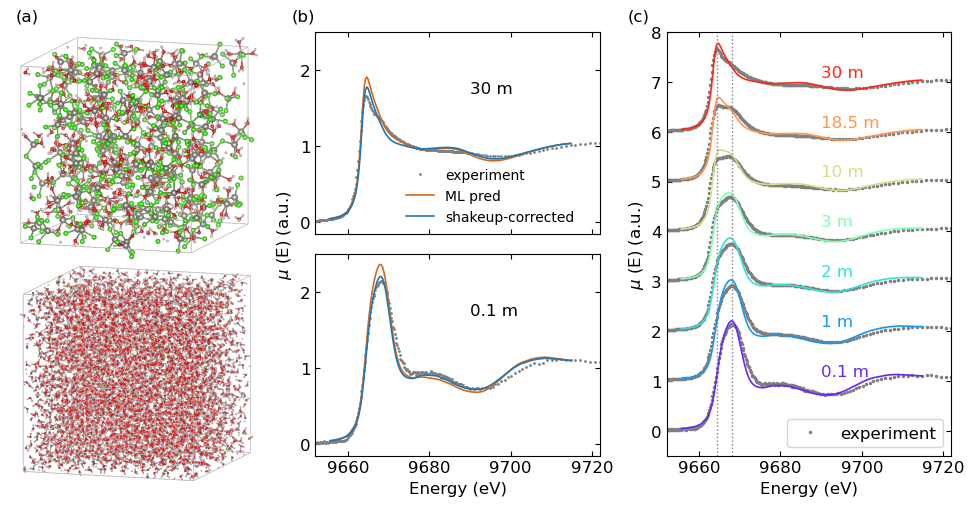

In [14]:
close('all')
plt.rc("font", size=12)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

fig = plt.figure(figsize=(12, 5.5))
main_gs = GridSpec(1, 3, figure=fig, width_ratios=[0.8, 1, 1], wspace=0.25) 
gs_col1 = GridSpecFromSubplotSpec(2, 1, subplot_spec=main_gs[0], hspace=0.15)
axs_col1 = [fig.add_subplot(gs_col1[i, 0]) for i in range(2)]
gs_col2 = GridSpecFromSubplotSpec(2, 1, subplot_spec=main_gs[1], hspace=0.1)
axs_col2 = [fig.add_subplot(gs_col2[i, 0]) for i in range(2)]
ax3 = fig.add_subplot(main_gs[2])

ax = axs_col1[0]
img = Image.open('./data/data-prediction/snapshot-30m.png')
ax.imshow(img)# .crop((0, 20, 900, 860)))
ax.axis('off')
# Expand by 5% on each side
pos = ax.get_position()

ax = axs_col1[1]
img = Image.open('./data/data-prediction/snapshot-0.1m.png')
ax.imshow(img)
ax.axis('off')
for ax in axs_col1: 
    pos = ax.get_position()
    expansion = 0.05
    ax.set_position([
        pos.x0 - 2*expansion * pos.width, 
        pos.y0 - 5*expansion * pos.height,
        pos.width * (1 + 4*expansion), 
        pos.height * (1 + 6.5*expansion)
    ])


labels='bc'
nn=0
for ax, idx in zip(axs_col2, [6, 0]): 
    molality = molality_list[idx]
    sp_exp = dict_exp[molality]
    sp_pred = dict_pred[molality]['ave']
    sp_pred_shakeup = dict_pred[molality]['ave-shakeup']
    ax.plot(sp_exp[0], sp_exp[1], linestyle='none', marker='o', color='gray', ms=1, label='experiment')
    ax.plot(energy_grid[1:-1]+SHIFT, sp_pred[1][1:-1], lw=1.2, color='chocolate', label='ML pred')
    ax.plot(energy_grid[1:-1]+SHIFT, sp_pred_shakeup[1][1:-1], lw=1.2, color='C0', label='shakeup-corrected')
    # ax.annotate('(%s) %s m'%(labels[nn],molality), xy=(9690, 1.7)) 
    ax.annotate('%s m'%(molality), xy=(9690, 1.7)) 
    nn+=1
axs_col2[0].legend(fontsize=10, frameon=False, loc=(0.3,0.02))
axs_col2[1].set_xlabel('Energy (eV)')
axs_col2[0].set_ylabel('$\mu$ (E) (a.u.)', y=0)
for ax in axs_col2: 
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.set_ylim(-0.15, 2.5)
    ax.set_xlim(9650+2, 9730-8)
    ax.set_yticks(np.arange(0, 3))
    ax.set_yticklabels((0,1,2))
axs_col2[0].set_xticklabels([])
    

ax = ax3

nn = 0
scale = 1
for molality in molality_list: 
    sp_exp = dict_exp[molality]
    sp_pred = dict_pred[molality]['ave-shakeup']
    ax.plot(sp_exp[0], sp_exp[1] + nn*scale, linestyle='none', marker='o', color='gray', ms=1.5)
    ax.plot(energy_grid[1:-1]+SHIFT, sp_pred[1][1:-1] + nn*scale, lw=1.2, color=color[nn])
    ax.annotate('%s m'%molality, xy=(9690, nn+1.1), color=color[nn])
    nn += 1
ax.plot([0,1],[0,1], linestyle='none', marker='o', color='gray', ms=1.5, label='experiment')
ax.axvline(x=9664.5, linestyle=':', lw=1, color='gray')
ax.axvline(x=9668, linestyle=':', lw=1, color='gray')
ax.legend()
ax.set_xlim(9650+2, 9730-8)
ax.set_ylim(-0.5, 8)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$\mu$ (E) (a.u.)')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

fig.text(0.12, 0.90, '(a)', fontsize=12)
fig.text(0.35, 0.90, '(b)', fontsize=12)
fig.text(0.63, 0.90, '(c)', fontsize=12)
# plt.savefig('./figures/large_snapshots-shakeup-experiment.png', bbox_inches='tight', dpi=200)

Text(0, 1, '$\\mu$ (E) (a.u.)')

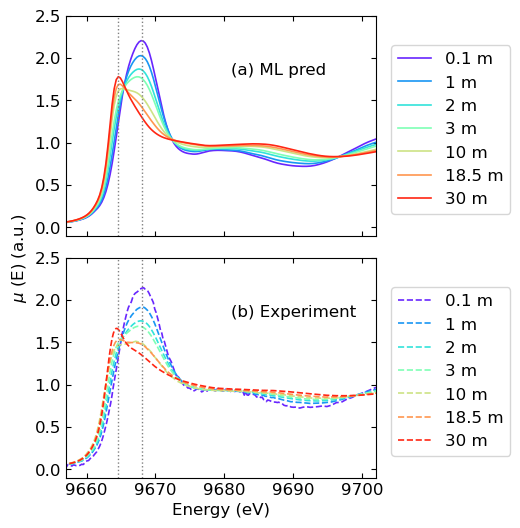

In [15]:
close('all')
plt.rc("font", size=12)
fig, axs = plt.subplots(2, 1, figsize=(4, 6), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

nn = 0
scale = 0
ax = axs[0]
for molality in molality_list: 
    sp_exp = dict_exp[molality]
    sp_pred = dict_pred[molality]['ave-shakeup']
    axs[0].plot(energy_grid[1:-1]+SHIFT, sp_pred[1][1:-1] + nn*scale, lw=1.2, color=color[nn], label='%s m'%molality)
    axs[1].plot(sp_exp[0], sp_exp[1] + nn*scale, linestyle='--', color=color[nn], lw=1.2, label='%s m'%molality)
    nn += 1
xx, yy = [9681, 1.8]
axs[0].annotate('(a) ML pred', xy=(xx, yy))
axs[1].annotate('(b) Experiment', xy=(xx, yy))

for ax in axs: 
    ax.legend(loc=(1.05, 0.1))
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.axvline(x=9664.5, linestyle=':', lw=1, color='gray')
    ax.axvline(x=9668, linestyle=':', lw=1, color='gray')
ax.set_xlim(9650+2+5, 9730-8-20)
ax.set_ylim(-0.1, 2.5)
axs[1].set_xlabel('Energy (eV)')
axs[1].set_ylabel('$\mu$ (E) (a.u.)', y=1)

# plt.savefig('./figures/SI-shakeup-experiment.png', bbox_inches='tight', dpi=150)

### 3. UMAP

In [16]:
umap_all = np.load("./data/umap.npy")

In [17]:
cn_Cl, cn_O, cn_Cl_2nd, cn_O_2nd, cn_Zn, cluster_labels = np.loadtxt("./data/CN-FSS-SSS.txt", unpack=True)

In [18]:
mean_sp = []
rep_sp = []
for i in range(6): 
    data = np.loadtxt("./data/mean_spec-cluster_%s.txt"%i)
    mean_sp.append(data[:,1])
    data = np.loadtxt("./data/rep_spec-cluster_%s.txt"%i)
    rep_sp.append(data[:,1])    

Text(0.67, 0.47, '(f)')

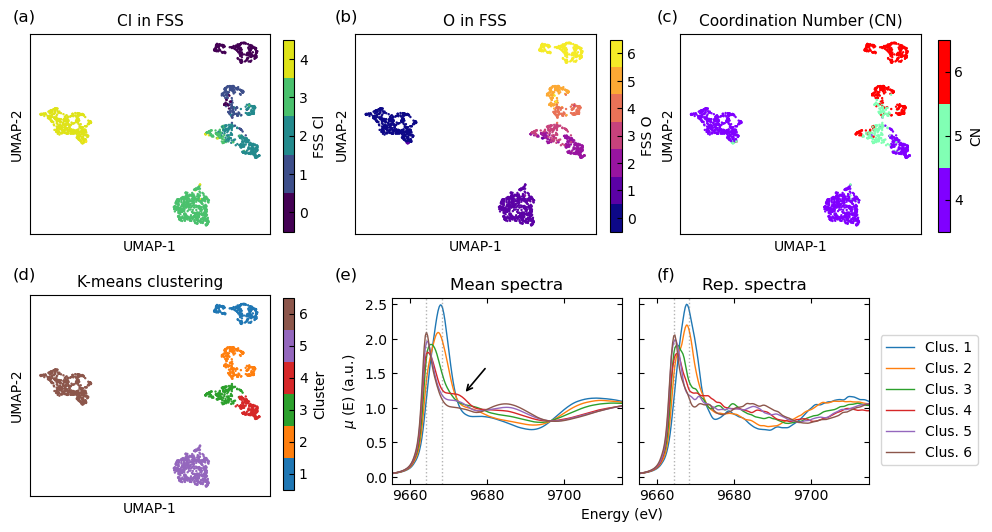

In [19]:
close('all')
plt.rc("font", size=10)
fig, axs = plt.subplots(2, 3, figsize=(11.5, 6), sharex=False, sharey=False)
plt.subplots_adjust(hspace=0.3, wspace=0.35)
axs = axs.flatten()

cbar_x = 0.345
cbar_y = 0.55
cbar_x_shift=0.285
cbar_y_shift=-0.43
font_title=11
markersize=0.5

ax = axs[0]
pos1 = ax.scatter(umap_all[:, 0], umap_all[:, 1], s=markersize, c = cn_Cl, vmax=4.2, cmap='viridis')#, alpha=0.8)
cbar_ax1 = fig.add_axes([cbar_x, cbar_y, 0.01, 0.32])
fig.colorbar(pos1, cax=cbar_ax1, ticks=np.arange(5), values=np.arange(5), label='FSS Cl')
ax.set_title("Cl in FSS", fontsize=font_title)

ax = axs[1]
pos1 = ax.scatter(umap_all[:, 0], umap_all[:, 1], s=markersize, c = cn_O, vmax=6.2, cmap='plasma')#, alpha=0.8)
cbar_ax1 = fig.add_axes([cbar_x+cbar_x_shift, cbar_y, 0.01, 0.32])
fig.colorbar(pos1, cax=cbar_ax1, ticks=np.arange(7), values=np.arange(7), label='FSS O')
ax.set_title("O in FSS", fontsize=font_title)

ax = axs[2]
pos1 = ax.scatter(umap_all[:, 0], umap_all[:, 1], s=markersize, c = cn_Cl+cn_O, cmap='rainbow')#, alpha=0.8)
cbar_ax1 = fig.add_axes([cbar_x+2*cbar_x_shift, cbar_y, 0.01, 0.32])
fig.colorbar(pos1, cax=cbar_ax1, ticks=np.arange(7), values=np.arange(4, 7), label='CN')
ax.set_title("Coordination Number (CN)", fontsize=font_title)

ax = axs[3]
pos1 = ax.scatter(umap_all[:, 0], umap_all[:, 1], s=markersize, c = cluster_labels+1, vmin=0.5, vmax=10.5, cmap='tab10')#, alpha=0.8)
cbar_ax1 = fig.add_axes([cbar_x, cbar_y+cbar_y_shift, 0.01, 0.32])
fig.colorbar(pos1, cax=cbar_ax1, ticks=np.arange(1, 7), values=np.arange(1, 7), label='Cluster')
ax.set_title("K-means clustering", fontsize=font_title)

for ax in axs[:4]: 
    ax.set_xlabel('UMAP-1')#, labelpad=-5)
    ax.set_ylabel('UMAP-2')#, labelpad=-5)
    ax.set_xticks([])
    ax.set_yticks([])
for ax in axs[4:]: 
    ax.axis('off')

xs, ys, w, h = 0.44, 0.13, 0.20, 0.31
ax4 = fig.add_axes([xs, ys, w, h])
ax = ax4
for i in range(6): 
    ax.plot(energy_grid + SHIFT, mean_sp[i], label=f"Cluster {i+1}", lw=1)
# ax.legend()
ax.set_title("Mean spectra")
ax.annotate('', xy=(9674, 1.2), xytext=(9680, 1.6),
            arrowprops=dict(facecolor='k', arrowstyle='->', lw=1.2))

ax5 = fig.add_axes([xs+0.215, ys, w, h])
ax = ax5
for i in range(6): 
    ax.plot(energy_grid + SHIFT, rep_sp[i], label=f"Clus. {i+1}", lw=1)
ax.legend(loc=(1.05, 0.1), fontsize=10)
ax.set_yticklabels([])
ax.set_title("Rep. spectra")

for ax in [ax4, ax5]: 
    ax.set_xlim(energy_grid[0] + SHIFT,energy_grid[-1] + SHIFT)
    ax.set_ylim(-0.1, 2.6)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.axvline(x=8959+SHIFT, linestyle=":", color='gray', alpha=0.6, lw=1)
    ax.axvline(x=8963+SHIFT, linestyle=":", color='gray', alpha=0.6, lw=1)    
ax4.set_xlabel("Energy (eV)", x=1)
ax4.set_ylabel('$\mu$ (E) (a.u.)')

fig.text(0.11, 0.90, '(a)', fontsize=12)
fig.text(0.39, 0.90, '(b)', fontsize=12)
fig.text(0.67, 0.90, '(c)', fontsize=12)
fig.text(0.11, 0.47, '(d)', fontsize=12)
fig.text(0.39, 0.47, '(e)', fontsize=12)
fig.text(0.67, 0.47, '(f)', fontsize=12)
# plt.savefig('./data-figure/UMAP.png', bbox_inches='tight', dpi=150)

Text(0.69, 0.92, '(c)')

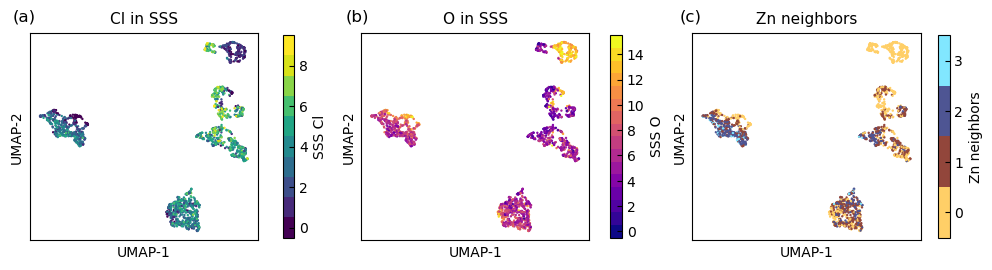

In [20]:
close('all')
plt.rc("font", size=10)
fig, axs = plt.subplots(1, 3, figsize=(11.5, 2.7), sharex=False, sharey=False)
plt.subplots_adjust(hspace=0.3, wspace=0.45)
axs = axs.flatten()

cbar_x = 0.345
cbar_y = 0.12
cbar_h = 0.75
cbar_x_shift=0.285
cbar_y_shift=-0.43
font_title=11
markersize=0.5


ax = axs[0]
pos1 = ax.scatter(umap_all[:, 0], umap_all[:, 1], s=markersize, c = cn_Cl_2nd, vmax=8.5)#, alpha=0.8)
cbar_ax1 = fig.add_axes([cbar_x, cbar_y, 0.01, cbar_h])
fig.colorbar(pos1, cax=cbar_ax1, ticks=np.arange(0, 10, 2), values=np.arange(0,10), label='SSS Cl')
ax.set_title("Cl in SSS", fontsize=font_title)

ax = axs[1]
pos1 = ax.scatter(umap_all[:, 0], umap_all[:, 1], s=markersize, c = cn_O_2nd, vmax=15, cmap='plasma')#, alpha=0.8)
cbar_ax1 = fig.add_axes([cbar_x+cbar_x_shift, cbar_y, 0.01, cbar_h])
fig.colorbar(pos1, cax=cbar_ax1, ticks=np.arange(0, 16, 2), values=np.arange(0, 16), label='SSS O')
ax.set_title("O in SSS", fontsize=font_title)

ax = axs[2]
pos1 = ax.scatter(umap_all[:, 0], umap_all[:, 1], s=markersize, c = cn_Zn, vmin=0, vmax=3, cmap='managua')#, alpha=0.8)
cbar_ax1 = fig.add_axes([cbar_x+2*cbar_x_shift, cbar_y, 0.01, cbar_h])
fig.colorbar(pos1, cax=cbar_ax1, ticks=np.arange(4), values=np.arange(4), label='Zn neighbors')
ax.set_title("Zn neighbors", fontsize=font_title)

for ax in axs: 
    ax.set_xlabel('UMAP-1')#, labelpad=-5)
    ax.set_ylabel('UMAP-2')#, labelpad=-5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.text(0.11, 0.92, '(a)', fontsize=12)
fig.text(0.40, 0.92, '(b)', fontsize=12)
fig.text(0.69, 0.92, '(c)', fontsize=12)
# plt.savefig('./data-figure/SI-UMAP-SSS.png', bbox_inches='tight', dpi=150)

### 4. Node attribution + PDOS

In [41]:
dict_pdos_attr = pickle.load(open('./data/dict_pdos_attr.pkl', 'rb'))

In [42]:
dict_color = {
    'Cl': 'g', 
    'O': 'brown', 
    'Zn': 'gray', 
}

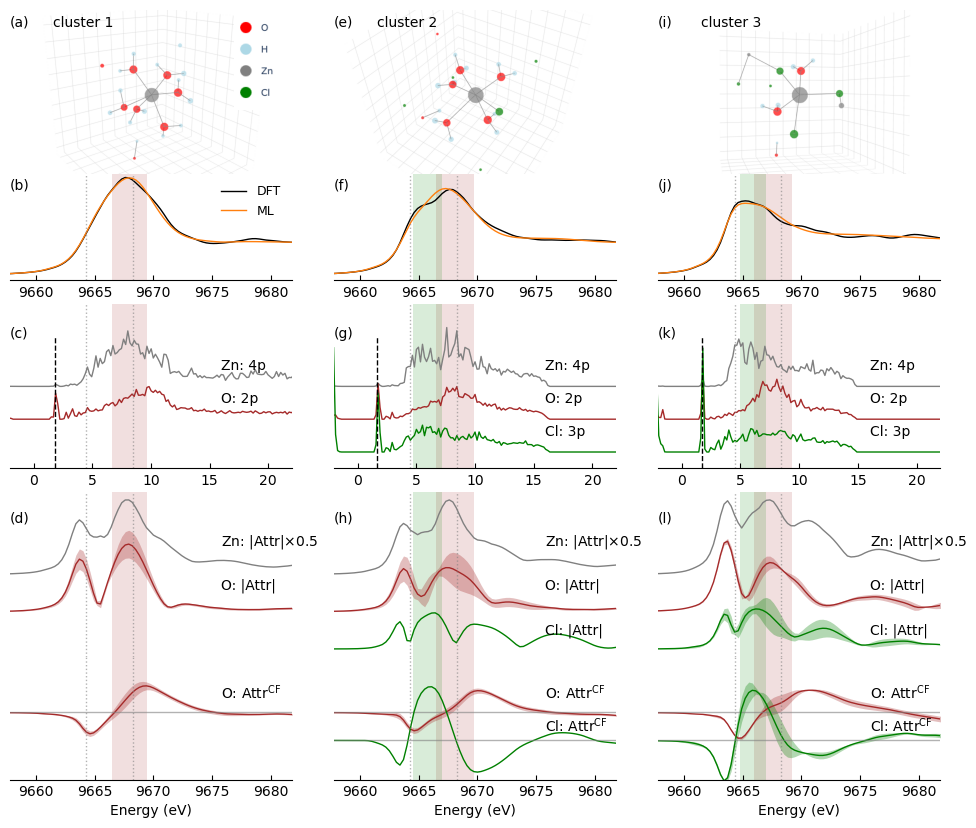

In [43]:
shift = -8960 + 5.5  ## Shift between simulated spectra and PDOS

close('all')
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc("font", size=10)
wspace=0.15

fig = plt.figure(figsize=(12, 10))
main_gs = GridSpec(3, 1, figure=fig, height_ratios=[3.3, 2, 3.5], hspace=0.1)  # No space between sections
gs_row01 = GridSpecFromSubplotSpec(2, 3, subplot_spec=main_gs[0], height_ratios=[2, 1.3], wspace=wspace, hspace=0)
axs_row0 = [fig.add_subplot(gs_row01[0, i]) for i in range(3)]
axs_row1 = [fig.add_subplot(gs_row01[1, i]) for i in range(3)]
gs_row2 = GridSpecFromSubplotSpec(1, 3, subplot_spec=main_gs[1], wspace=wspace)
axs_row2 = [fig.add_subplot(gs_row2[0, i]) for i in range(3)]
gs_rows34 = GridSpecFromSubplotSpec(2, 3, subplot_spec=main_gs[2], height_ratios=[2, 1.5], hspace=0, wspace=wspace)
axs_row3 = [fig.add_subplot(gs_rows34[0, i]) for i in range(3)]
axs_row4 = [fig.add_subplot(gs_rows34[1, i]) for i in range(3)]
# Combine into array-like structure
axs = [axs_row1, axs_row2, axs_row3, axs_row4]

ax_lg = fig.add_axes((0.31, .78, 0.04, 0.10))
img = Image.open('./data/legend.png')
ax_lg.imshow(img)  
ax_lg.axis('off')

for cluster_idx in range(3): 
    
    ax_img = axs_row0[cluster_idx]
    ax_sp = axs_row1[cluster_idx]
    ax_pdos = axs_row2[cluster_idx]
    ax_attr = axs_row3[cluster_idx]
    ax_cf_attr = axs_row4[cluster_idx]
    pdos_attr = dict_pdos_attr[cluster_idx]
    
    img = Image.open('./data/cluster_%s.png'%cluster_idx)
    ax_img.imshow(img.crop((100, 250, 900, 750))) 
    
    ax_sp.plot(energy_grid+shift, pdos_attr['sp_dft'], color='k', lw=1, label='DFT')
    ax_sp.plot(energy_grid+shift, pdos_attr['sp_pred'], color='C1', lw=1, label='ML')
    
    nn = 0
    scale = 0.5
    element = 'Zn'
    attr = pdos_attr['attr_%s'%element]
    ax_attr.plot(energy_grid+shift, (2-nn) * scale + attr, label=element+': |Attr|', color=dict_color[element], lw=1)

    for nn, element in enumerate(['O', 'Cl'], start=1): 
        if 'attr_%s'%element in pdos_attr: 
            attr = pdos_attr['attr_%s'%element] * 2
            attr_mean = attr.mean(axis=1)
            attr_std = attr.std(axis=1)
            ax_attr.plot(energy_grid+shift, (2-nn) * scale + attr_mean, label=element+': |Attr|', color=dict_color[element], lw=1)
            ax_attr.fill_between(energy_grid+shift, (2-nn) * scale + attr_mean-attr_std, (2-nn) * scale + attr_mean+attr_std, 
                            alpha=0.3, color=dict_color[element], lw=0)


    for nn, element in enumerate(['O', 'Cl'], start=1): 
        if 'attr_cf_%s'%element in pdos_attr: 
            attr = pdos_attr['attr_cf_%s'%element]
            attr_mean = attr.mean(axis=1)
            attr_std = attr.std(axis=1)
            ax_cf_attr.plot(energy_grid+shift, (2-nn) * scale + attr_mean, label=element+': attr', color=dict_color[element], lw=1)
            ax_cf_attr.fill_between(energy_grid+shift, (2-nn) * scale + attr_mean-attr_std, (2-nn) * scale + attr_mean+attr_std, 
                            alpha=0.3, color=dict_color[element], lw=0)
            ax_cf_attr.axhline(y=(2-nn) * scale, lw=1, color='gray', alpha=0.6)
                
    ax = ax_pdos
    scale = 0.2
    dict_labels = {
        'Cl': '3p' ,
        'O': '2p' ,
        'Zn': '4p' ,
    }
    for nn, element in enumerate(['Zn', 'O', 'Cl']): 
        if 'pdos_%s'%element in pdos_attr: 
            energies, densities = pdos_attr['pdos_%s'%element]
            shift_pdos = pdos_attr['shift_pdos']
            ax.plot(energies + shift_pdos , (2-nn) * scale + densities,
                 linestyle='-', lw=1, label=element + ': ' + dict_labels[element], color=dict_color[element])
    ax.axvline(x=shift_pdos+pdos_attr['efermi'], ymax=0.8, color='k', lw=1, linestyle='--', label='Fermi')

    
for ax in axs_row1: 
    ax.set_ylim(-0.1, 2.6) 
    ax.set_xlim(-2, 22)
for ax in axs_row2: 
    ax.set_ylim(-0.1, 0.9)  
    ax.set_xlim(-2, 22)
for ax in axs_row3: 
    ax.set_ylim(-0.1, 2.1) 
    ax.set_xlim(-2, 22)
for ax in axs_row4: 
    ax.set_ylim(-0.7, 1.5) 
    ax.set_xlim(-2, 22)


for ax in axs_row1 + axs_row2 + axs_row3 + axs_row4: 
    ax.axvline(x=8959+shift, linestyle=":", color='gray', alpha=0.6, lw=1)
    ax.axvline(x=8963+shift, linestyle=":", color='gray', alpha=0.6, lw=1)

for ax in axs_row0 + axs_row3:
    ax.axis('off')
for ax in axs_row1 + axs_row2 + axs_row4:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False,labelleft=False)
for ax in axs_row4:
    ax.set_xlabel('Energy (eV)')
for ax in axs_row1 + axs_row4:
    ax.set_xticks(np.arange(0+0.5-0.3, 21+0.5-0.3, 5))
    ax.set_xticklabels(np.arange(int(-shift+SHIFT+0.5-0.3), int(-shift+SHIFT+21+0.5-0.3), 5))
    
axs_row1[0].legend(frameon=False, fontsize=9)
for ax in axs_row2: 
    ax.annotate("Zn: 4p", xy=(16, 0.5))
    ax.annotate("O: 2p", xy=(16, 0.3))
for ax in axs_row2[1:]: 
    ax.annotate("Cl: 3p", xy=(16, 0.1))
for ax in axs_row3: 
    ax.annotate("Zn: |Attr|"+r"${\times}$0.5", xy=(16, 1.4))
    ax.annotate("O: |Attr|", xy=(16, 0.8))
for ax in axs_row3[1:]: 
    ax.annotate("Cl: |Attr|", xy=(16, 0.2))
for ax in axs_row4: 
    ax.annotate("O: Attr"+r"$^\text{CF}$", xy=(16, 0.75))
for ax in axs_row4[1:]: 
    ax.annotate("Cl: Attr"+r"$^\text{CF}$", xy=(16, 0.15))

ii = 1
for ax, tt in zip(axs_row0, ['a', 'e', 'i']): 
    ax.text(-30, 50, "("+tt+")")
    ax.text(100, 50, "cluster %s"%ii)
    ii += 1
for ax, tt in zip(axs_row1, ['b', 'f', 'j']): 
    ax.text(-2, 2.2, "("+tt+")")
for ax, tt in zip(axs_row2, ['c', 'g', 'k']): 
    ax.text(-2, 0.7, "("+tt+")")
for ax, tt in zip(axs_row3, ['d', 'h', 'l']): 
    ax.text(-2, 1.7, "("+tt+")")
    
for ax in (axs_row1[0], axs_row2[0], axs_row3[0], axs_row4[0]):
    ax.axvspan(9668+shift-SHIFT-1.5, 9668+shift-SHIFT+1.5, alpha=0.15, facecolor='brown', edgecolor=None, zorder=-1)
for ax in (axs_row1[1], axs_row2[1], axs_row3[1], axs_row4[1]):
    ax.axvspan(9668+shift-SHIFT-1.5, 9668+shift-SHIFT+1.7, alpha=0.15, facecolor='brown', edgecolor=None, zorder=-1)
    ax.axvspan(9666+shift-SHIFT-1.5, 9666+shift-SHIFT+1, alpha=0.15, facecolor='g', edgecolor=None, zorder=-1)
# for ax in axs_row3:
#     ax.axvline(9664+shift-SHIFT)
#     ax.axvline(9666+shift-SHIFT)
#     ax.axvline(9668+shift-SHIFT)
#     ax.axvline(9671+shift-SHIFT)
for ax in (axs_row1[2], axs_row2[2], axs_row3[2], axs_row4[2]):
    ax.axvspan(9667.5+shift-SHIFT-1.5, 9667.5+shift-SHIFT+1.7, alpha=0.15, facecolor='brown', edgecolor=None, zorder=-1)
    ax.axvspan(9666+shift-SHIFT-1.2, 9666+shift-SHIFT+1, alpha=0.15, facecolor='g', edgecolor=None, zorder=-1)
    
# plt.savefig("./figures/node-xas-attr-pdos-cluster012.png", bbox_inches='tight', dpi=150)

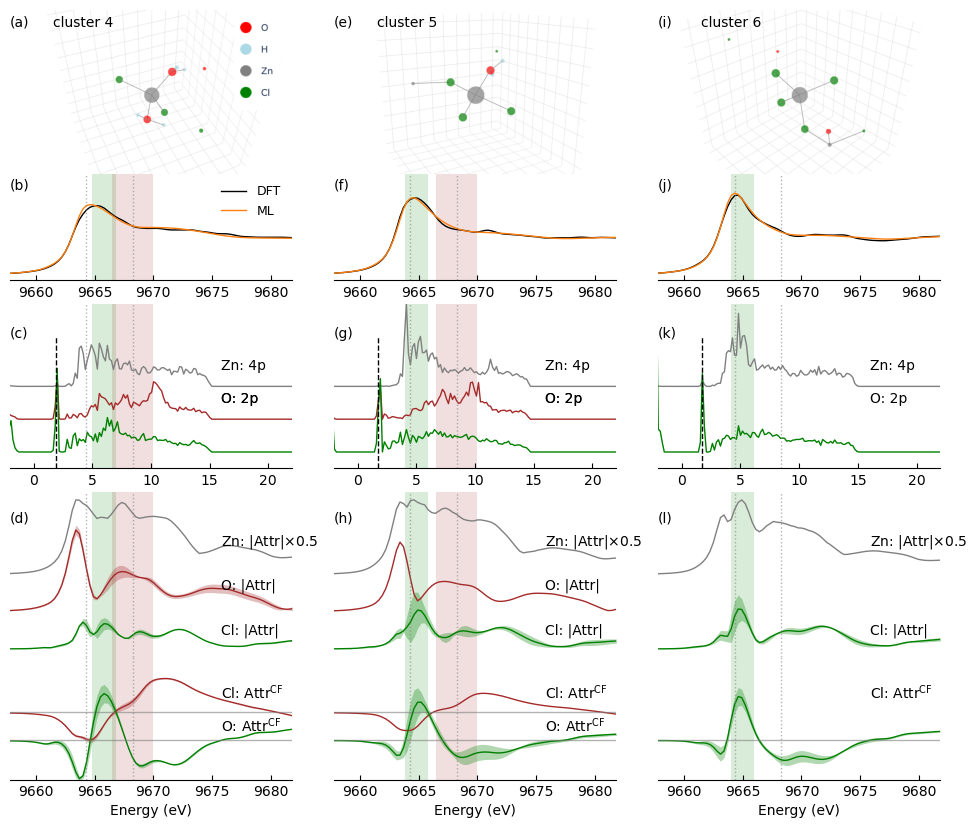

In [44]:
close('all')
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc("font", size=10)
wspace=0.15

fig = plt.figure(figsize=(12, 10))
main_gs = GridSpec(3, 1, figure=fig, height_ratios=[3.3, 2, 3.5], hspace=0.1)  # No space between sections
gs_row01 = GridSpecFromSubplotSpec(2, 3, subplot_spec=main_gs[0], height_ratios=[2, 1.3], wspace=wspace, hspace=0)
axs_row0 = [fig.add_subplot(gs_row01[0, i]) for i in range(3)]
axs_row1 = [fig.add_subplot(gs_row01[1, i]) for i in range(3)]
gs_row2 = GridSpecFromSubplotSpec(1, 3, subplot_spec=main_gs[1], wspace=wspace)
axs_row2 = [fig.add_subplot(gs_row2[0, i]) for i in range(3)]
gs_rows34 = GridSpecFromSubplotSpec(2, 3, subplot_spec=main_gs[2], height_ratios=[2, 1.5], hspace=0, wspace=wspace)
axs_row3 = [fig.add_subplot(gs_rows34[0, i]) for i in range(3)]
axs_row4 = [fig.add_subplot(gs_rows34[1, i]) for i in range(3)]
# Combine into array-like structure
axs = [axs_row1, axs_row2, axs_row3, axs_row4]

ax_lg = fig.add_axes((0.31, .78, 0.04, 0.10))
img = Image.open('./data/legend.png')
ax_lg.imshow(img)  
ax_lg.axis('off')

for cluster_idx in range(3, 6): 
    
    ax_img = axs_row0[cluster_idx-3]
    ax_sp = axs_row1[cluster_idx-3]
    ax_pdos = axs_row2[cluster_idx-3]
    ax_attr = axs_row3[cluster_idx-3]
    ax_cf_attr = axs_row4[cluster_idx-3]
    pdos_attr = dict_pdos_attr[cluster_idx]
    
    img = Image.open('./data/cluster_%s.png'%cluster_idx)
    ax_img.imshow(img.crop((100, 250, 900, 750))) 
    
    ax_sp.plot(energy_grid+shift, pdos_attr['sp_dft'], color='k', lw=1, label='DFT')
    ax_sp.plot(energy_grid+shift, pdos_attr['sp_pred'], color='C1', lw=1, label='ML')
    
    nn = 0
    scale = 0.5
    element = 'Zn'
    attr = pdos_attr['attr_%s'%element]
    ax_attr.plot(energy_grid+shift, (2-nn) * scale + attr, label=element+': |Attr|', color=dict_color[element], lw=1)

    for nn, element in enumerate(['O', 'Cl'], start=1): 
        if 'attr_%s'%element in pdos_attr: 
            attr = pdos_attr['attr_%s'%element] * 2
            attr_mean = attr.mean(axis=1)
            attr_std = attr.std(axis=1)
            ax_attr.plot(energy_grid+shift, (2-nn) * scale + attr_mean, label=element+': |Attr|', color=dict_color[element], lw=1)
            ax_attr.fill_between(energy_grid+shift, (2-nn) * scale + attr_mean-attr_std, (2-nn) * scale + attr_mean+attr_std, 
                            alpha=0.3, color=dict_color[element], lw=0)


    for nn, element in enumerate(['O', 'Cl'], start=1): 
        if 'attr_cf_%s'%element in pdos_attr: 
            attr = pdos_attr['attr_cf_%s'%element]
            attr_mean = attr.mean(axis=1)
            attr_std = attr.std(axis=1)
            ax_cf_attr.plot(energy_grid+shift, (2-nn) * scale + attr_mean, label=element+': attr', color=dict_color[element], lw=1)
            ax_cf_attr.fill_between(energy_grid+shift, (2-nn) * scale + attr_mean-attr_std, (2-nn) * scale + attr_mean+attr_std, 
                            alpha=0.3, color=dict_color[element], lw=0)
            ax_cf_attr.axhline(y=(2-nn) * scale, lw=1, color='gray', alpha=0.6)
                
    ax = ax_pdos
    scale = 0.2
    dict_labels = {
        'Cl': '3p' ,
        'O': '2p' ,
        'Zn': '4p' ,
    }
    for nn, element in enumerate(['Zn', 'O', 'Cl']): 
        if 'pdos_%s'%element in pdos_attr: 
            energies, densities = pdos_attr['pdos_%s'%element]
            shift_pdos = pdos_attr['shift_pdos']
            ax.plot(energies + shift_pdos , (2-nn) * scale + densities,
                 linestyle='-', lw=1, label=element + ': ' + dict_labels[element], color=dict_color[element])
    ax.axvline(x=shift_pdos+pdos_attr['efermi'], ymax=0.8, color='k', lw=1, linestyle='--', label='Fermi')

    
for ax in axs_row1: 
    ax.set_ylim(-0.1, 2.6) 
    ax.set_xlim(-2, 22)
for ax in axs_row2: 
    ax.set_ylim(-0.1, 0.9)  
    ax.set_xlim(-2, 22)
for ax in axs_row3: 
    ax.set_ylim(-0.1, 2.1) 
    ax.set_xlim(-2, 22)
for ax in axs_row4: 
    ax.set_ylim(-0.7, 1.5) 
    ax.set_xlim(-2, 22)


for ax in axs_row1 + axs_row2 + axs_row3 + axs_row4: 
    ax.axvline(x=8959+shift, linestyle=":", color='gray', alpha=0.6, lw=1)
    ax.axvline(x=8963+shift, linestyle=":", color='gray', alpha=0.6, lw=1)

for ax in axs_row0 + axs_row3:
    ax.axis('off')
for ax in axs_row1 + axs_row2 + axs_row4:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False,labelleft=False)
for ax in axs_row4:
    ax.set_xlabel('Energy (eV)')
for ax in axs_row1 + axs_row4:
    ax.set_xticks(np.arange(0+0.5-0.3, 21+0.5-0.3, 5))
    ax.set_xticklabels(np.arange(int(-shift+SHIFT+0.5-0.3), int(-shift+SHIFT+21+0.5-0.3), 5))
    
axs_row1[0].legend(frameon=False, fontsize=9)
for ax in axs_row2: 
    ax.annotate("Zn: 4p", xy=(16, 0.5))
    ax.annotate("O: 2p", xy=(16, 0.3))
for ax in axs_row2[:-1]: 
    ax.annotate("O: 2p", xy=(16, 0.3))
for ax in axs_row3: 
    ax.annotate("Zn: |Attr|"+r"${\times}$0.5", xy=(16, 1.4))
    # ax.annotate("Zn: |Attr|", xy=(16, 1.4))
    ax.annotate("Cl: |Attr|", xy=(16, 0.2))
for ax in axs_row3[:-1]: 
    ax.annotate("O: |Attr|", xy=(16, 0.8))
for ax in axs_row4: 
    ax.annotate("Cl: Attr"+r"$^\text{CF}$", xy=(16, 0.75))
for ax in axs_row4[:-1]: 
    ax.annotate("O: Attr"+r"$^\text{CF}$", xy=(16, 0.15))

ii = 4
for ax, tt in zip(axs_row0, ['a', 'e', 'i']): 
    ax.text(-30, 50, "("+tt+")")
    ax.text(100, 50, "cluster %s"%ii)
    ii += 1
for ax, tt in zip(axs_row1, ['b', 'f', 'j']): 
    ax.text(-2, 2.2, "("+tt+")")
for ax, tt in zip(axs_row2, ['c', 'g', 'k']): 
    ax.text(-2, 0.7, "("+tt+")")
for ax, tt in zip(axs_row3, ['d', 'h', 'l']): 
    ax.text(-2, 1.7, "("+tt+")")
    
for ax in (axs_row1[0], axs_row2[0], axs_row3[0], axs_row4[0]):
    ax.axvspan(9668.3+shift-SHIFT-1.8, 9668.3+shift-SHIFT+1.7, alpha=0.15, facecolor='brown', edgecolor=None, zorder=-1)
    ax.axvspan(9665.8+shift-SHIFT-1, 9665.8+shift-SHIFT+1, alpha=0.15, facecolor='g', edgecolor=None, zorder=-1)
    
for ax in (axs_row1[1], axs_row2[1], axs_row3[1], axs_row4[1]):
    ax.axvspan(9668.3+shift-SHIFT-1.8, 9668.3+shift-SHIFT+1.7, alpha=0.15, facecolor='brown', edgecolor=None, zorder=-1)
    ax.axvspan(9664.8+shift-SHIFT-1, 9664.8+shift-SHIFT+1, alpha=0.15, facecolor='g', edgecolor=None, zorder=-1)
    
for ax in (axs_row1[2], axs_row2[2], axs_row3[2], axs_row4[2]):
    ax.axvspan(9665+shift-SHIFT-1, 9665+shift-SHIFT+1, alpha=0.15, facecolor='g', edgecolor=None, zorder=-1)
# for ax in axs_row3:
#     ax.axvline(9664+shift-SHIFT)
#     ax.axvline(9666+shift-SHIFT)
#     ax.axvline(9668+shift-SHIFT)
#     ax.axvline(9671+shift-SHIFT)    
    
# plt.savefig("./figures/node-xas-attr-pdos-cluster345.png", bbox_inches='tight', dpi=150)

### 5. Edge attribution

In [45]:
dict_edge_attr = pickle.load(open('./data/dict_edge_attr.pkl', 'rb'))

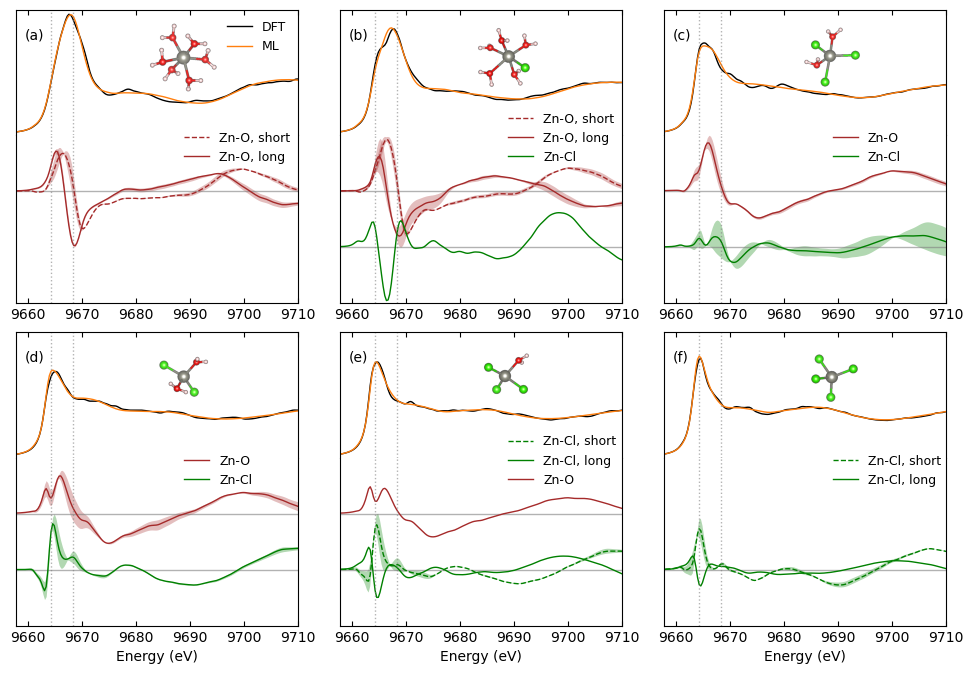

In [46]:
dict_color_ls = {
    'long': '-', 
    'short': '--', 
    'Cl': 'g', 
    'O': 'brown'
}   

close('all')
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc("font", size=10)
wspace=0.15
scale = 1

fig = plt.figure(figsize=(12, 8))
main_gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 1], hspace=0.1)  # No space between sections
gs_row1 = GridSpecFromSubplotSpec(2, 3, subplot_spec=main_gs[0], height_ratios=[1.5, 2], hspace=0, wspace=wspace)
axs_row11 = [fig.add_subplot(gs_row1[0, i]) for i in range(3)]
axs_row12 = [fig.add_subplot(gs_row1[1, i]) for i in range(3)]

gs_row2 = GridSpecFromSubplotSpec(2, 3, subplot_spec=main_gs[1], height_ratios=[1.5, 2], hspace=0, wspace=wspace)
axs_row21 = [fig.add_subplot(gs_row2[0, i]) for i in range(3)]
axs_row22 = [fig.add_subplot(gs_row2[1, i]) for i in range(3)]

axs_sp = axs_row11 + axs_row21
axs_attr = axs_row12 + axs_row22


for cluster_idx in range(6): 
    ax_sp = axs_sp[cluster_idx]
    sp_attr = dict_edge_attr[cluster_idx]
    ax_sp.plot(energy_grid, sp_attr['sp_dft'], color='k', lw=1, label='DFT')
    ax_sp.plot(energy_grid, sp_attr['sp_pred'], color='C1', lw=1, label='ML')

    ax_attr = axs_attr[cluster_idx]
    nn = 0
    if cluster_idx != 5:
        ax_attr.axhline(y=(1-nn) * scale, lw=1, color='gray', alpha=0.6)
    nn = 1
    if cluster_idx != 0:
        ax_attr.axhline(y=(1-nn) * scale, lw=1, color='gray', alpha=0.6)

for cluster_idx, dist_cut, select_element in zip(range(6), [2.1, 2.1, 0, 0, 2.3, 2.3], [None, 'Cl', 'OCl', 'OCl', 'O', None]): 
    ax_attr = axs_attr[cluster_idx]
    sp_attr = dict_edge_attr[cluster_idx]
    if dist_cut != 0: 
        select_short = sp_attr['dist'] < dist_cut
        select_long = sp_attr['dist'] >= dist_cut
        if dist_cut == 2.1: 
            nn = 0
            color = dict_color_ls['O']
            label_element = 'O'
            for ii, el in enumerate(sp_attr['element']): 
                if el == 'Cl':
                    select_short[ii] = False
                    select_long[ii] = False
        else: 
            nn = 1
            color = dict_color_ls['Cl']
            label_element = 'Cl'
            for ii, el in enumerate(sp_attr['element']): 
                if el == 'O':
                    select_short[ii] = False
                    select_long[ii] = False            
        attr_short_mean = np.mean(sp_attr['attr'][select_short], axis=0)
        attr_short_std = np.std(sp_attr['attr'][select_short], axis=0)   
        attr_long_mean = np.mean(sp_attr['attr'][select_long], axis=0)
        attr_long_std = np.std(sp_attr['attr'][select_long], axis=0)        
        ax_attr.plot(energy_grid, (1-nn) * scale + attr_short_mean, label='Zn-' + label_element+', short', color=color, ls=dict_color_ls['short'], lw=1)
        ax_attr.fill_between(energy_grid, (1-nn) * scale + attr_short_mean-attr_short_std, (1-nn) * scale + attr_short_mean+attr_short_std, 
                        alpha=0.3, color=color, ls=dict_color_ls['short'], lw=0)
        ax_attr.plot(energy_grid, (1-nn) * scale + attr_long_mean, label='Zn-' + label_element+', long', color=color, ls=dict_color_ls['long'], lw=1)
        ax_attr.fill_between(energy_grid, (1-nn) * scale + attr_long_mean-attr_long_std, (1-nn) * scale + attr_long_mean+attr_long_std, 
                        alpha=0.3, color=color, ls=dict_color_ls['long'], lw=0)
    if select_element is not None: 
        select_O = np.zeros(len(sp_attr['element']), dtype=bool)
        select_Cl = np.zeros(len(sp_attr['element']), dtype=bool)
        for ii, el in enumerate(sp_attr['element']): 
            select_Cl[ii] = el == 'Cl'
            select_O[ii] = el == 'O'
        attr_Cl_mean = np.mean(sp_attr['attr'][select_Cl], axis=0)
        attr_Cl_std = np.std(sp_attr['attr'][select_Cl], axis=0)
        attr_O_mean = np.mean(sp_attr['attr'][select_O], axis=0)
        attr_O_std = np.std(sp_attr['attr'][select_O], axis=0)
        
        nn = 0
        if 'O' in select_element: 
            ax_attr.plot(energy_grid, (1-nn) * scale + attr_O_mean, label='Zn-O' , color=dict_color_ls['O'], lw=1)
            ax_attr.fill_between(energy_grid, (1-nn) * scale + attr_O_mean-attr_O_std, (1-nn) * scale + attr_O_mean+attr_O_std, 
                            alpha=0.3, color=dict_color_ls['O'], lw=0)
        nn += 1
        if 'Cl' in select_element: 
            ax_attr.plot(energy_grid, (1-nn) * scale + attr_Cl_mean, label='Zn-Cl', color=dict_color_ls['Cl'], lw=1)
            ax_attr.fill_between(energy_grid, (1-nn) * scale + attr_Cl_mean-attr_Cl_std, (1-nn) * scale + attr_Cl_mean+attr_Cl_std, 
                            alpha=0.3, color=dict_color_ls['Cl'], lw=0)



for ax in axs_row11+axs_row21: 
    ax.set_ylim(0, 2.6) 
for ax in axs_row12 + axs_row22: 
    ax.set_ylim(-1, 2) 

for ax in axs_row11 + axs_row21 + axs_row12 + axs_row22: 
    ax.axvline(x=8959, linestyle=":", color='gray', alpha=0.6, lw=1)
    ax.axvline(x=8963, linestyle=":", color='gray', alpha=0.6, lw=1)
    ax.set_xlim(-shift-2, -shift+50)

for ax in axs_row11 + axs_row21:
    ax.spines['bottom'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    ax.tick_params(left=False,labelleft=False, bottom=False, top=True, labelbottom=False)
    # ax.xaxis.set_ticks_position('top')
    # ax.axis('off')
for ax in axs_row12 + axs_row22:
    ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    ax.tick_params(left=False,labelleft=False, top=False)
for ax in axs_row22:
    ax.set_xlabel('Energy (eV)')
for ax in axs_row11 +axs_row21+ axs_row12 + axs_row22:
    ax.set_xticks(np.arange(-shift+0.5-0.3, -shift+51+0.5-0.3, 10))
    ax.set_xticklabels(np.arange(int(-shift+SHIFT+0.5-0.3), int(-shift+SHIFT+51+0.5-0.3), 10))
    
axs_row11[0].legend(frameon=False, fontsize=9)
for ax in axs_row12+axs_row22:
    ax.legend(frameon=False, fontsize=9, loc=(0.58,0.8))
    
ii = 1
for ax, tt in zip(axs_row11, ['a', 'b', 'c']): 
    ax.text(9659.5-SHIFT, 2.0, "("+tt+")")
    # ax.text(100, 50, "cluster %s"%ii)
    ii += 1
for ax, tt in zip(axs_row21, ['d', 'e', 'f']): 
    ax.text(9659.5-SHIFT, 2.0, "("+tt+")")

scale_h = 0.27
scale_v = 0.4
for cluster_idx in range(6): 
    hh = cluster_idx % 3
    vv = int(cluster_idx / 3)
    ax_im = fig.add_axes((0.23+hh*scale_h, .77-scale_v*vv, 0.07, 0.10))
    img = Image.open('./data/POSCAR-cluster-%s.png'%cluster_idx)
    ax_im.imshow(img)  
    ax_im.axis('off')
    nn += 1
    
# plt.savefig("./figures/edge-xas-attr.png", bbox_inches='tight', dpi=150)

### 6. Illustration

In [27]:
def create_workflow_figure(spectrum_data, 
                          element_types=("O", "H", "Zn", "Cl")):
    """
    Create complete workflow: Structure → Graph → Spectrum
    """
    fig = plt.figure(figsize=(10, 4))
    
    # ax1 = fig.add_subplot(131)
    ax1 = fig.add_axes((0.01, 0.1, 0.26, 0.8))
    structure_img = plt.imread('./data/POSCAR-structure-50.png')  # Your VESTA image
    ax1.imshow(structure_img)
    ax1.axis('off')


    # ax2 = fig.add_subplot(132)
    ax2 = fig.add_axes((0.31, 0.05, 0.33, 0.85))
    graph_img = plt.imread('./data/graph_representation-structure-50.png')  # Your VESTA image
    ax2.imshow(graph_img)
    ax2.set_aspect('equal')
    ax2.axis('off')
    
    # ax3 = fig.add_subplot(133)
    ax3 = fig.add_axes((0.72, 0.25, 0.28, 0.55))
    energy, intensity = spectrum_data  # Your spectrum data
    ax3.plot(energy, intensity, 'chocolate', linewidth=2)
    # ax3.fill_between(energy, intensity, alpha=0.3)
    ax3.set_xlabel('Energy (eV)', fontsize=12)
    ax3.set_ylabel('Intensity (a.u.)', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.tick_params(left=False,labelleft=False)
    
    # Add "GNN" label
    fig.text(0.65, 0.42, 'ML', fontsize=14, ha='center', va='center',
             fontweight='bold', style='italic',
             # bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
             bbox=dict(facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    return fig

In [28]:
sp_idx = 50
pred_spectrum_cpu = np.loadtxt("./data/illustration_spec-pred-structure_%s-%s-%s-%s.txt"%(sp_idx, nblocks, cutoff, threebody_cutoff), unpack=True)[1]

/tmp/ipykernel_1687974/2296367177.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


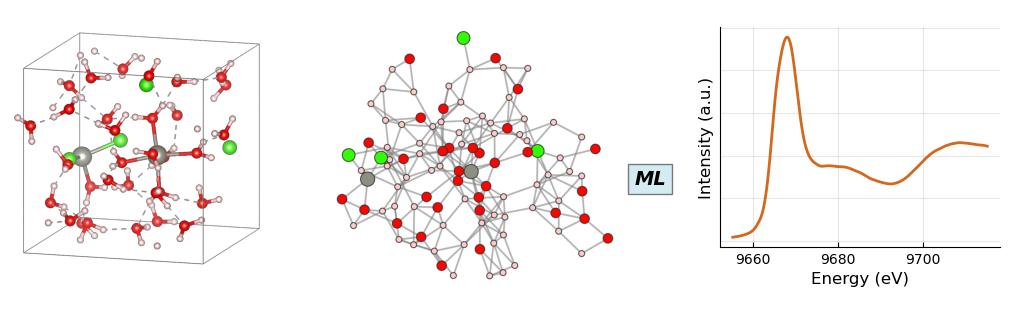

In [29]:
fig = create_workflow_figure((energy_grid+SHIFT, pred_spectrum_cpu))
# plt.savefig('./figures/workflow.png', dpi=300, bbox_inches='tight')